In [1]:
import sys
print(sys.executable)

/gpfs/home3/scur2635/comicspap-project/venv/bin/python


In [2]:
import regex
print(regex.__version__)
print(regex.__file__)

2.5.145
/sw/arch/RHEL9/EB_production/2024/software/Python-bundle-PyPI/2024.06-GCCcore-13.3.0/lib/python3.12/site-packages/regex/__init__.py


In [3]:
import sys

# 1. Path del venv
venv_path = "/gpfs/home3/scur2635/comicspap-project/venv/lib/python3.12/site-packages"

# 2. Pulizia profonda dei moduli pre-caricati che causano conflitti
for mod in ['regex', 'numpy', 'scipy']:
    if mod in sys.modules:
        del sys.modules[mod]

# 3. Priorità assoluta al venv
sys.path = [venv_path] + [p for p in sys.path if venv_path not in p]

# 4. Verifica Versioni
import numpy as np
import regex
print(f"NumPy version: {np.__version__} (Deve essere 1.x)")
print(f"Regex version: {regex.__version__} (Deve essere 2026.x)")
print(f"Regex file: {regex.__file__}")

# 5. Ora gli import pesanti
import torch
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
print("Import completati con successo! ✅")

NumPy version: 1.26.4 (Deve essere 1.x)
Regex version: 2026.3.32 (Deve essere 2026.x)
Regex file: /gpfs/home3/scur2635/comicspap-project/venv/lib/python3.12/site-packages/regex/__init__.py
Import completati con successo! ✅


In [4]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from peft import PeftModel
import torch

base_model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
adapter_path = "/scratch-shared/scur2635/comicspap/checkpoints/qlora_v2_r32_sequence_filling_20260401_225549/checkpoint-300"

print("1. Caricamento modello base (senza device_map automatico per PEFT)...")
# Carichiamo il modello direttamente sulla GPU 0 per evitare conflitti di mappatura
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    base_model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": 0} # Forziamo tutto sulla prima GPU
)

print("2. Iniezione pesi LoRA...")
# Usiamo il costruttore PeftModel direttamente
model = PeftModel.from_pretrained(
    model, 
    adapter_path,
    device_map={"": 0} # Manteniamo la stessa mappatura
)

print("3. Finalizzazione...")
model.eval()
processor = AutoProcessor.from_pretrained(adapter_path)

print("Modello Qwen2.5-VL + LoRA caricato correttamente! ✅")

1. Caricamento modello base (senza device_map automatico per PEFT)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

2. Iniezione pesi LoRA...
3. Finalizzazione...
Modello Qwen2.5-VL + LoRA caricato correttamente! ✅


In [4]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
import torch

# 1. Definiamo solo l'ID originale del modello
base_model_id = "Qwen/Qwen2.5-VL-7B-Instruct"

print("1. Caricamento modello base ORIGINALE (senza LoRA)...")
# Carichiamo il modello standard
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    base_model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": 0} # Tutto sulla prima GPU
)

print("2. Finalizzazione...")
model.eval()

# Usiamo il processor originale di Qwen
processor = AutoProcessor.from_pretrained(base_model_id)

print("Modello Qwen2.5-VL BASE caricato correttamente! 🚀")

1. Caricamento modello base ORIGINALE (senza LoRA)...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

2. Finalizzazione...
Modello Qwen2.5-VL BASE caricato correttamente! 🚀


In [5]:
import os
import sys

# 1. Imposta la variabile d'ambiente per la cache di Hugging Face
os.environ['HF_DATASETS_CACHE'] = "/scratch-shared/scur2635/comicspap/hf_cache"

# 2. (Opzionale ma consigliato) Aggiungi anche il path del progetto ai moduli
project_root = "/gpfs/home3/scur2635/comicspap-project/official_repo"
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from datasets import load_dataset
from data_utils import SingleImagePickAPanel

# 3. Carica il dataset: ora lo leggerà istantaneamente da scratch-shared!
ds_val = load_dataset("VLR-CVC/ComicsPAP", "sequence_filling", split="val")

print(f"Dataset caricato correttamente! Numero esempi: {len(ds_val)}")

/gpfs/home3/scur2635/comicspap-project/venv/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.0' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/gpfs/home3/scur2635/comicspap-project/venv/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.8' currently installed).
  from pandas.core import (


Resolving data files:   0%|          | 0/105 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/240 [00:00<?, ?it/s]

Dataset caricato correttamente! Numero esempi: 262


✅ Font trovato: /home/scur2635/comicspap-project/assets/DejaVuSans.ttf


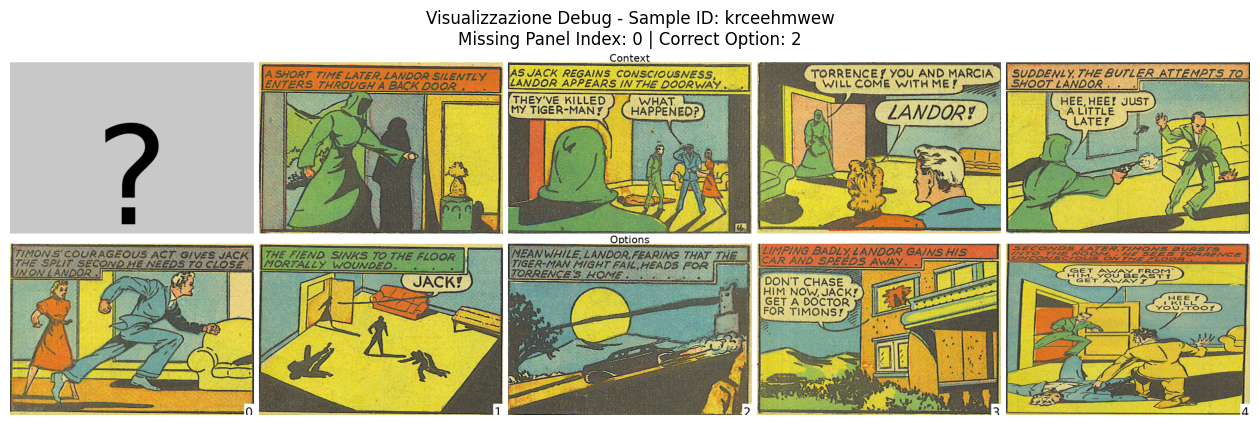

In [6]:
import os
import matplotlib.pyplot as plt
from data_utils import SingleImagePickAPanel
import matplotlib.pyplot as plt
%matplotlib inline

# 1. Definizione Path Assoluto
font_path = "/home/scur2635/comicspap-project/assets/DejaVuSans.ttf"

# Check di sicurezza: il file esiste davvero?
if not os.path.exists(font_path):
    print(f"❌ ERRORE: Il file non esiste in {font_path}")
    # Proviamo a vedere cosa c'è in quella cartella
    print("Contenuto della cartella assets:", os.listdir("/home/scur2635/comicspap-project/assets/"))
else:
    print(f"✅ Font trovato: {font_path}")

# 2. Inizializzazione Processore
panel_processor = SingleImagePickAPanel(font_path=font_path)

# 3. Composizione dell'immagine (Esempio 15)
sample = ds_val[55]
batch_examples = {k: [v] for k, v in sample.items()}
processed_batch = panel_processor.map_to_single_image(batch_examples)
single_image = processed_batch['single_image'][0]

# 4. Plot finale
plt.figure(figsize=(16, 10))
plt.imshow(single_image)
plt.title(f"Visualizzazione Debug - Sample ID: {sample['sample_id']}\n"
          f"Missing Panel Index: {sample['index']} | Correct Option: {sample['solution_index']}", 
          fontsize=12)
plt.axis('off')
plt.show()

In [7]:
import torch
from qwen_vl_utils import process_vision_info

# 1. Configurazione del Prompt (deve essere identico a quello del training)
system_prompt = (
    "Pick A Panel Task: In the image you have two rows of comic panels. "
    "The top row is the context and the bottom row is the options. "
    "The context row has a missing panel marked with a question mark. "
    "Choose the option that best fills the gap in the sequence. "
    "Respond with only the option number."
)

# Recuperiamo la caption se presente (aiuta il modello a contestualizzare)
caption = sample.get('previous_panel_caption', '')
print(f"--- DEBUG DATA ---")
print(f"Caption fornita: {caption if caption else 'Nessuna'}")
print(f"Risposta corretta (GT): {sample['solution_index']}\n")

# 2. Preparazione del messaggio per il Processor
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": system_prompt},
            {"type": "text", "text": f"Previous panel caption: {caption}" if caption else ""},
            {"type": "image", "image": single_image}, # L'immagine che hai appena visualizzato
        ],
    }
]

# 3. Trasformazione in Input per il Modello
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)

inputs = processor(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt"
).to(model.device)

# 4. Ispezione dei Token (Cosa "vede" il modello a livello numerico)
print(f"--- TOKEN INSPECTION ---")
input_ids = inputs['input_ids'][0]
print(f"Lunghezza totale sequenza: {len(input_ids)} token")
# Cerchiamo i tag speciali di visione
vision_start_id = processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
vision_end_id = processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
print(f"Token visivi rilevati: {'SÌ' if vision_start_id in input_ids else 'NO'}")

# 5. GENERAZIONE (Il ragionamento)
with torch.no_grad():
    generated_ids = model.generate(
        **inputs, 
        max_new_tokens=15, # Ci aspettiamo solo un numero, 15 sono più che sufficienti
        do_sample=False,   # Greedy decoding per vedere la scelta "pura" del modello
        temperature=0.0    # Massima determinazione
    )

# 6. Decodifica e Analisi Output
# Tagliamo il prompt per vedere solo cosa ha scritto l'Assistant
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

output_text = processor.batch_decode(
    generated_ids_trimmed, 
    skip_special_tokens=True, 
    clean_up_tokenization_spaces=False
)[0]

raw_output = processor.tokenizer.decode(generated_ids[0], skip_special_tokens=False)

print(f"\n--- MODEL OUTPUT ---")
print(f"Raw Output (con tutti i tag): \n{raw_output[-100:]}") # Vediamo gli ultimi 100 char
print(f"\nRISPOSTA FINALE: '{output_text.strip()}'")

# Verifica logica
is_correct = str(output_text.strip()) == str(sample['solution_index'])
print(f"RISULTATO: {'✅ CORRETTO' if is_correct else '❌ SBAGLIATO'}")

--- DEBUG DATA ---
Caption fornita: Nessuna
Risposta corretta (GT): 2

--- TOKEN INSPECTION ---
Lunghezza totale sequenza: 2233 token


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Token visivi rilevati: SÌ

--- MODEL OUTPUT ---
Raw Output (con tutti i tag): 
d|><|image_pad|><|image_pad|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant
1<|im_end|>

RISPOSTA FINALE: '1'
RISULTATO: ❌ SBAGLIATO


In [8]:
import collections

# --- 1. VERIFICA STATO LORA ---
print("--- DIAGNOSTICA LORA ---")
if hasattr(model, "active_adapters"):
    print(f"Adapter attivi: {model.active_adapters}")
    # Verifichiamo se ci sono parametri con 'lora' nel nome che hanno gradienti o pesi caricati
    lora_params = [n for n, p in model.named_parameters() if "lora_" in n]
    print(f"Parametri LoRA trovati nel modello: {len(lora_params)}")
    if len(lora_params) == 0:
        print("⚠️ ATTENZIONE: Nessun parametro LoRA trovato. Il checkpoint potrebbe non essere stato caricato!")
else:
    print("⚠️ Il modello non sembra essere un PeftModel.")

# --- 2. TEST SU 20 CAMPIONI ---
print("\n--- TEST DISTRIBUZIONE (Tutto il Val Set) ---")
results = []
predictions = []
ground_truths = []

# Prendiamo 20 indici dal validation set
test_indices = np.random.choice(np.arange(0,262), size=262, replace=False)

for i in test_indices:
    sample = ds_val[i]
    
    # Processamento immagine
    batch_examples = {k: [v] for k, v in sample.items()}
    processed_batch = panel_processor.map_to_single_image(batch_examples)
    img = processed_batch['single_image'][0]
    
    # Prompt
    caption = sample.get('previous_panel_caption', '')
    messages = [{"role": "user", "content": [
        {"type": "text", "text": system_prompt},
        {"type": "image", "image": img}
    ]}]
    
    # Inferenza
    text_inp = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inp, _ = process_vision_info(messages)
    inputs = processor(text=[text_inp], images=image_inp, padding=True, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=5, do_sample=False)
    
    # Decode
    gen_trimmed = [out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)]
    pred = processor.batch_decode(gen_trimmed, skip_special_tokens=True)[0].strip()
    
    predictions.append(pred)
    ground_truths.append(str(sample['solution_index']))
    print(f"Sample {i}: Pred='{pred}' | GT='{sample['solution_index']}'")

# --- 3. ANALISI DISTRIBUZIONE ---
counter = collections.Counter(predictions)
print("\n--- STATISTICHE FINALI ---")
print(f"Distribuzione risposte modello: {dict(counter)}")
accuracy = sum(1 for p, g in zip(predictions, ground_truths) if p == g) / len(predictions)
print(f"Accuratezza su 20 campioni: {accuracy:.2%}")

if len(counter) == 1:
    print("\n⚠️ COLLASSO DELLE RISPOSTE: Il modello risponde sempre la stessa cosa. "
          "Probabilmente il LoRA non è addestrato abbastanza o il caricamento ha ignorato i pesi.")

--- DIAGNOSTICA LORA ---
Adapter attivi: ['default']
Parametri LoRA trovati nel modello: 584

--- TEST DISTRIBUZIONE (Tutto il Val Set) ---
Sample 25: Pred='3' | GT='4'
Sample 83: Pred='2' | GT='2'
Sample 42: Pred='4' | GT='4'
Sample 254: Pred='2' | GT='2'
Sample 151: Pred='4' | GT='4'
Sample 212: Pred='2' | GT='3'
Sample 137: Pred='2' | GT='0'
Sample 197: Pred='1' | GT='1'
Sample 173: Pred='2' | GT='1'
Sample 187: Pred='3' | GT='3'
Sample 120: Pred='3' | GT='1'
Sample 214: Pred='2' | GT='2'
Sample 85: Pred='3' | GT='1'
Sample 181: Pred='1' | GT='4'
Sample 143: Pred='4' | GT='0'
Sample 218: Pred='1' | GT='1'
Sample 12: Pred='4' | GT='0'
Sample 192: Pred='3' | GT='3'
Sample 201: Pred='4' | GT='3'
Sample 132: Pred='0' | GT='1'
Sample 232: Pred='2' | GT='1'
Sample 36: Pred='2' | GT='2'
Sample 131: Pred='4' | GT='4'
Sample 228: Pred='3' | GT='3'
Sample 225: Pred='4' | GT='4'
Sample 170: Pred='0' | GT='0'
Sample 204: Pred='4' | GT='4'
Sample 147: Pred='2' | GT='3'
Sample 205: Pred='0' | GT=

=== ISPEZIONE ESEMPIO 12 ===
Target Corretto (GT): 0
Indice del '?' nel Context: 1


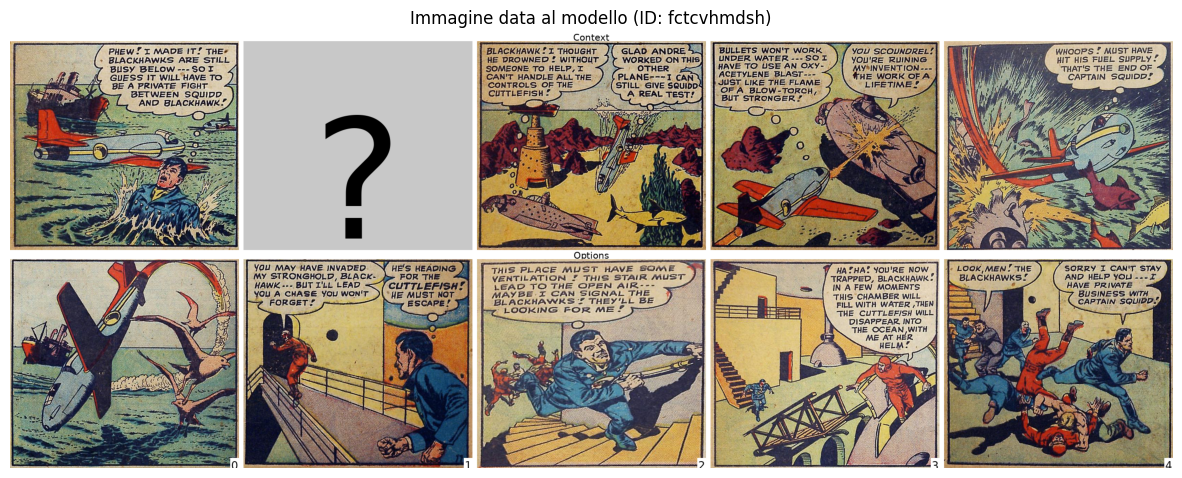


=== ANALISI TOKEN E INPUT ID ===
Prompt testuale inviato:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Pick A Panel Task: In the image you have two rows of comic panels. The top row is the context and the bottom row is the options. The context row has a missing panel marked with a question mark. Choose the option that best fills the gap in the sequence. Respond with only the option number.<|vision_start|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant


Shape dei pixel values: torch.Size([12376, 1176])
Numero totale di input token: 3177
Token <|vision_start|> trovato all'indice: 76
Numero di token <|image_pad|>: 3094

=== RISULTATO GENERAZIONE ===
RAW OUTPUT (Full): ...><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|vision_end|><|im_end|>
<|im_start|>assistant
3<|im_end|>

RISPOSTA PULITA: '3'
TARGET ATTESO:   '0'


In [28]:
import torch
from qwen_vl_utils import process_vision_info
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE ---
idx_to_inspect = 12 # Cambia questo per vedere diversi esempi
sample = ds_val[idx_to_inspect]

# 1. PREPARAZIONE IMMAGINE E PROMPT
panel_processor = SingleImagePickAPanel(font_path="/home/scur2635/comicspap-project/assets/DejaVuSans.ttf")
processed_batch = panel_processor.map_to_single_image({k: [v] for k, v in sample.items()})
single_image = processed_batch['single_image'][0]

prompt_text = (
    "Pick A Panel Task: In the image you have two rows of comic panels. "
    "The top row is the context and the bottom row is the options. "
    "The context row has a missing panel marked with a question mark. "
    "Choose the option that best fills the gap in the sequence. "
    "Respond with only the option number."
)
caption = sample.get('previous_panel_caption', '')

messages = [{"role": "user", "content": [
    {"type": "text", "text": prompt_text},
    {"type": "text", "text": f"Previous panel caption: {caption}" if caption else ""},
    {"type": "image", "image": single_image}
]}]

# 2. VISUALIZZAZIONE INPUT (COSA VEDI TU)
print(f"=== ISPEZIONE ESEMPIO {idx_to_inspect} ===")
print(f"Target Corretto (GT): {sample['solution_index']}")
print(f"Indice del '?' nel Context: {sample['index']}")

plt.figure(figsize=(15, 8))
plt.imshow(single_image)
plt.title(f"Immagine data al modello (ID: {sample['sample_id']})")
plt.axis('off')
plt.show()

# 3. TRASFORMAZIONE IN TOKEN (COSA VEDE IL MODELLO)
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, _ = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, padding=True, return_tensors="pt").to(model.device)

print("\n=== ANALISI TOKEN E INPUT ID ===")
print(f"Prompt testuale inviato:\n{text}")
print(f"\nShape dei pixel values: {inputs['pixel_values'].shape}")
print(f"Numero totale di input token: {inputs['input_ids'].shape[1]}")

# Controlliamo la presenza dei token immagine
input_ids_list = inputs['input_ids'][0].tolist()
img_start_token = processor.tokenizer.convert_tokens_to_ids("<|vision_start|>")
img_end_token = processor.tokenizer.convert_tokens_to_ids("<|vision_end|>")
pad_token = processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")

print(f"Token <|vision_start|> trovato all'indice: {input_ids_list.index(img_start_token) if img_start_token in input_ids_list else 'NON TROVATO'}")
print(f"Numero di token <|image_pad|>: {input_ids_list.count(pad_token)}")

# 4. GENERAZIONE E RAW OUTPUT (COSA RISPONDE IL MODELLO)
with torch.no_grad():
    generated_ids = model.generate(
        **inputs, 
        max_new_tokens=15, 
        do_sample=False,
        return_dict_in_generate=True,
        output_scores=True
    )

# Decodifica dell'output completo (incluso il prompt per vedere i tag di chiusura)
full_decode = processor.tokenizer.decode(generated_ids.sequences[0], skip_special_tokens=False)
# Solo la parte generata
gen_only = full_decode.split("<|im_start|>assistant")[-1]

print("\n=== RISULTATO GENERAZIONE ===")
print(f"RAW OUTPUT (Full): ...{full_decode[-150:]}") # Vediamo solo la fine che è la parte interessante
print(f"\nRISPOSTA PULITA: '{gen_only.replace('<|im_end|>', '').strip()}'")
print(f"TARGET ATTESO:   '{sample['solution_index']}'")